# **EXPLORATORY DATA ANALYSIS**

In this notebook, we are going to do an Exploratory Data Analysis `(EDA)`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

First, we need to load our dataset about `Student Performance`, in this case, I downloaded the .csv file in my drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the dataset using the function `pd.read_csv()`, and assign it to a variable called `df`.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Student_Performance.csv")

## **DATA UNDERSTANDING**

The first step in EDA is to understand the data we are working with. We can use the following functions to get a better understanding of our dataset:

The shape of the dataset. (In this case, we have 10000 rows and 6 columns)

In [4]:
df.shape

(10000, 6)

The names of the columns.

In [5]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In this case we have the following columns:
* `Hours Studied`: The number of hours the student studies per week.
* `Previous Scores`: The scores the student obtained in previous assessments.
* `ExtraCurricular Activities`: Whether the student participates in extracurricular activities (Yes/No).
* `Sleep Hours`: The number of hours the student sleeps per night.
* `Sample Question Papers Practiced`: The number of sample question papers the student has practiced.
* `Performance Index`: The target variable we want to predict, which is a score that represents the overall performance of the student.

The data types of each column.

In [6]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


Now, we will use the function `df.head()` to see the first 5 rows of our dataset.

In [7]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


We also can use the method `df.tail()` to see the last 5 rows of our dataset.

In [8]:
df.tail(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


Let's see the descriptive statistics of our dataset.

In [9]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## **DATA PREPARATION**

In this step, we will prepare our data for analysis. We will check for missing values, outliers, and duplicates.

In this case, we will train machine learning models for a regression problem, so we need that all the features to be numerical. Perhaps, the dataset countain one categorical feature (`ExtraCurricular Activities`), so we need to encode this feature to be able to use it in our models. We will map the categorical values to numerical ones.

* `Yes` -> 1
* `No` -> 0

In [10]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({"Yes": 1, "No":0})

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [12]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


### **CORRELATION ANALYSIS**

In [13]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


In [ ]:
df.corr()['Performance Index'].sort_values(ascending=False)

,Performance Index
Performance Index,1.000000
Previous Scores,0.915189
Hours Studied,0.373730
Sleep Hours,0.048106
Sample Question Papers Practiced,0.043268
Extracurricular Activities,0.024525


IMPORTANT: We need see if we have any null values in our dataset.

In [15]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [16]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


Let's see the distribution of our variables using a histogram.

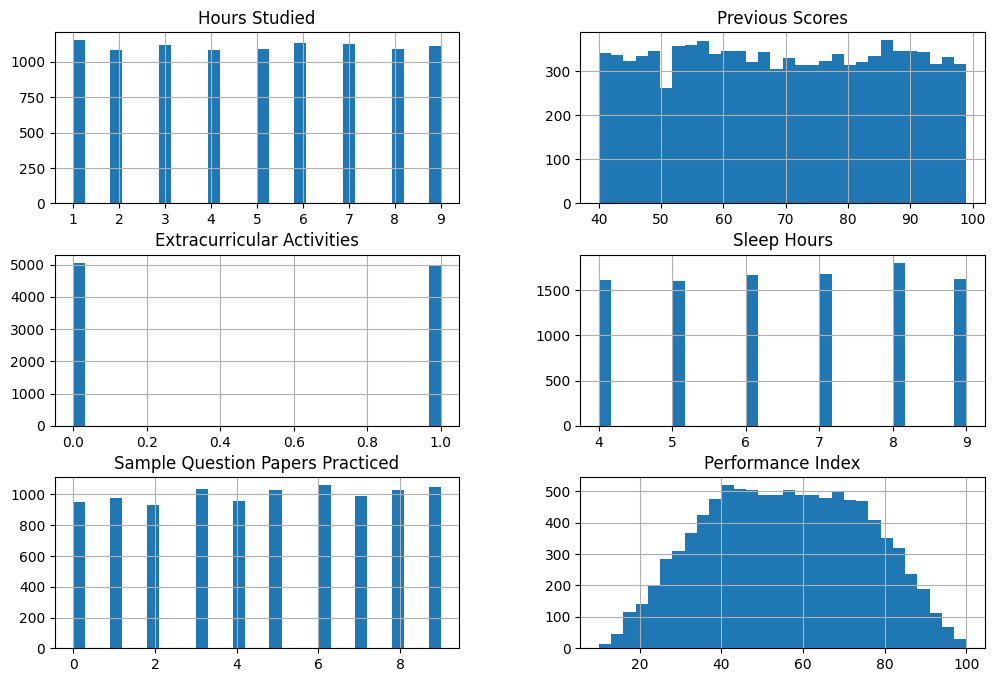

In [17]:
df.hist(bins=30, figsize=(12, 8))
plt.show()